In [1]:
import sys, os
sys.path.append('..')
sys.path.insert(0, os.path.abspath('../environments/secret_envs_lib'))
from secret_envs_wrapper import SecretEnv1

import numpy as np
import matplotlib.pyplot as plt

from algorithms.monte_carlo import monte_carlo_es, on_policy_first_visit_mc_control, off_policy_mc_control
from algorithms.temporal_difference_learning import sarsa, q_learning
from algorithms.planning import dyna_q, dyna_q_plus
from eval import evaluate_policy

# On se place dans le dossier contenant libs/ juste le temps de charger la DLL
_original_cwd = os.getcwd()
os.chdir(os.path.abspath('../environments/secret_envs_lib'))
env = SecretEnv1()
os.chdir(_original_cwd)  # on revient à la normale juste après

env.current_state = env.state_id
env.max_state_count = env.num_states
env.max_actions_count = env.num_actions

print("Nombre d'états :", env.max_state_count())
print("Nombre d'actions :", env.max_actions_count())

Nombre d'états : 65536
Nombre d'actions : 3


In [2]:
np.random.seed(0)
pi_mc_es, Q_mc_es = monte_carlo_es(env, gamma=0.999, num_episodes=5000, max_steps=200)
results_mc_es = evaluate_policy(env, pi_mc_es, num_episodes=500, max_steps=200)
print("Monte Carlo ES :", results_mc_es)

Monte Carlo ES : {'mean_score': 6.0, 'std_score': 0.0, 'win_rate': 1.0}


In [3]:
np.random.seed(0)
pi_on_mc, Q_on_mc = on_policy_first_visit_mc_control(env, gamma=0.999, epsilon=0.1, num_episodes=5000, max_steps=200)
results_on_mc = evaluate_policy(env, pi_on_mc, num_episodes=500, max_steps=200)
print("On-policy MC :", results_on_mc)

On-policy MC : {'mean_score': 23.0, 'std_score': 0.0, 'win_rate': 1.0}


In [4]:
np.random.seed(0)
pi_off_mc, Q_off_mc = off_policy_mc_control(env, gamma=0.999, num_episodes=5000, max_steps=200)
results_off_mc = evaluate_policy(env, pi_off_mc, num_episodes=500, max_steps=200)
print("Off-policy MC :", results_off_mc)

Off-policy MC : {'mean_score': -21.0, 'std_score': 0.0, 'win_rate': 0.0}


In [5]:
np.random.seed(0)
pi_sarsa, Q_sarsa = sarsa(env, gamma=0.999, alpha=0.1, epsilon=0.1, num_episodes=5000, max_steps=200)
results_sarsa = evaluate_policy(env, pi_sarsa, num_episodes=500, max_steps=200)
print("Sarsa :", results_sarsa)

Sarsa : {'mean_score': 11.0, 'std_score': 0.0, 'win_rate': 1.0}


In [6]:
np.random.seed(0)
pi_qlearning, Q_qlearning = q_learning(env, gamma=0.999, alpha=0.1, epsilon=0.1, num_episodes=5000, max_steps=200)
results_qlearning = evaluate_policy(env, pi_qlearning, num_episodes=500, max_steps=200)
print("Q-Learning :", results_qlearning)

Q-Learning : {'mean_score': 9.0, 'std_score': 0.0, 'win_rate': 1.0}


In [7]:
np.random.seed(0)
Q_dyna, pi_dyna = dyna_q(env, gamma=0.999, alpha=0.1, epsilon=0.1, max_steps=50000, N=10)
results_dyna = evaluate_policy(env, pi_dyna, num_episodes=500, max_steps=200)
print("Dyna-Q :", results_dyna)

np.random.seed(0)
Q_dyna_plus, pi_dyna_plus = dyna_q_plus(env, gamma=0.999, alpha=0.1, epsilon=0.1, max_steps=50000, N=10, kappa=0.001)
results_dyna_plus = evaluate_policy(env, pi_dyna_plus, num_episodes=500, max_steps=200)
print("Dyna-Q+ :", results_dyna_plus)

Dyna-Q : {'mean_score': 1.0, 'std_score': 0.0, 'win_rate': 1.0}
Dyna-Q+ : {'mean_score': 18.0, 'std_score': 0.0, 'win_rate': 1.0}


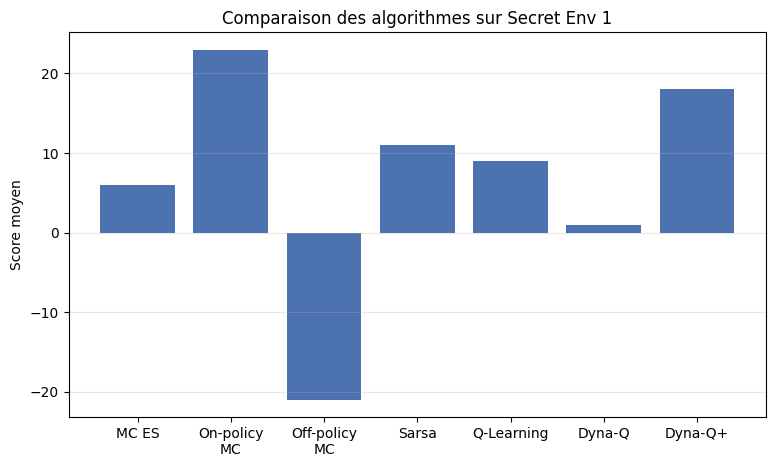

In [8]:
algos_names = ["MC ES", "On-policy\nMC", "Off-policy\nMC", "Sarsa", "Q-Learning", "Dyna-Q", "Dyna-Q+"]
mean_scores = [results_mc_es["mean_score"], results_on_mc["mean_score"], results_off_mc["mean_score"],
               results_sarsa["mean_score"], results_qlearning["mean_score"],
               results_dyna["mean_score"], results_dyna_plus["mean_score"]]

plt.figure(figsize=(9, 5))
plt.bar(algos_names, mean_scores, color="#4C72B0")
plt.ylabel("Score moyen")
plt.title("Comparaison des algorithmes sur Secret Env 1")
plt.grid(True, axis="y", alpha=0.3)
plt.savefig("secretenv1_comparaison_algos.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
t0 = time.time()
pi_pi_sparse, V_pi_sparse = sparse_policy_iteration(reachable_states, transitions, gamma=0.999, theta=0.0001)
print(f"Policy Iteration termine en {time.time()-t0:.1f}s")
print(f"V(etat de depart) = {V_pi_sparse[start_state]:.4f}")

Policy Iteration termine en 59.2s
V(etat de depart) = 29.8023
